# 06b — Análise de Erros e Custo Operacional

**Conteúdo Mínimo atendido:** CM 5.2 (análise de erros e justificativa do threshold).

Este notebook responde a três perguntas críticas para o negócio:

1. **Quanto custa errar?** Um falso negativo (parada não planejada) e um falso positivo (inspeção desnecessária) têm custos muito diferentes.
2. **Qual threshold é ótimo na perspectiva financeira**, e quanto economizamos vs. o threshold ótimo de F1?
3. **Onde o modelo erra?** Quais casos representativos de falso positivo e falso negativo explicam suas falhas.

Pipeline reproduzível: `uv run python src/sprint2_error_cost_analysis.py`.

In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent
data = json.loads((ROOT / 'outputs' / 'gold' / 'error_cost_analysis.json').read_text())
fig_dir = ROOT / 'outputs' / 'figures'

assumptions = data['cost_assumptions']
print('Premissas de custo (ordem de grandeza, BRL):')
for k, v in assumptions.items():
    print(f'  {k}: {v}')

Premissas de custo (ordem de grandeza, BRL):
  COST_FN_BRL: 50000
  COST_FP_BRL: 800
  ratio_FN_FP: 62.5
  rationale: FN = parada não planejada ~4h × R$12.500/h. FP = inspeção preventiva ~1h.


## 1. Matriz de custo: FN vs FP

**Falso Negativo (FN):** o modelo previu que não haveria Don't Go, mas houve. Custo: parada não planejada do equipamento, ~4h de indisponibilidade × R$ 12.500/h (custo médio de oportunidade de um caminhão 793-D). **R$ 50.000 por evento.**

**Falso Positivo (FP):** o modelo alertou, mas não ocorreu Don't Go. Custo: inspeção preventiva desnecessária + parada operacional curta. **R$ 800 por evento.**

**Razão de custo FN/FP = 62,5×.** Em problemas operacionais críticos, o threshold puramente otimizado por F1 raramente coincide com o ótimo financeiro.

## 2. Threshold ótimo por custo vs por F1

In [2]:
tr = data['test_results_by_threshold']
df = pd.DataFrame([
    {
        'Critério': 'F1 ótimo (val Mai)',
        'Threshold': tr['f1_optimo']['threshold'],
        'TP': tr['f1_optimo']['TP'],
        'FP': tr['f1_optimo']['FP'],
        'FN': tr['f1_optimo']['FN'],
        'F1': tr['f1_optimo']['F1'],
        'Recall': tr['f1_optimo']['recall'],
        'Custo total (R$)': tr['f1_optimo']['cost_BRL'],
    },
    {
        'Critério': 'Custo ótimo (val Mai)',
        'Threshold': tr['custo_otimo']['threshold'],
        'TP': tr['custo_otimo']['TP'],
        'FP': tr['custo_otimo']['FP'],
        'FN': tr['custo_otimo']['FN'],
        'F1': tr['custo_otimo']['F1'],
        'Recall': tr['custo_otimo']['recall'],
        'Custo total (R$)': tr['custo_otimo']['cost_BRL'],
    },
])
display(df.style.format({
    'Threshold': '{:.3f}', 'F1': '{:.4f}', 'Recall': '{:.4f}',
    'Custo total (R$)': 'R$ {:,.0f}',
}))

delta = data['delta_cost_test_BRL']
print(f"\nEconomia ao usar threshold custo-ótimo: R$ {delta:,.0f}")

,Critério,Threshold,TP,FP,FN,F1,Recall,Custo total (R$)
0,F1 ótimo (val Mai),0.930,22782,9740,12421,0.6728,0.6472,"R$ 628,842,000"
1,Custo ótimo (val Mai),0.510,31916,223734,3287,0.2195,0.9066,"R$ 343,337,200"



Economia ao usar threshold custo-ótimo: R$ 285,504,800


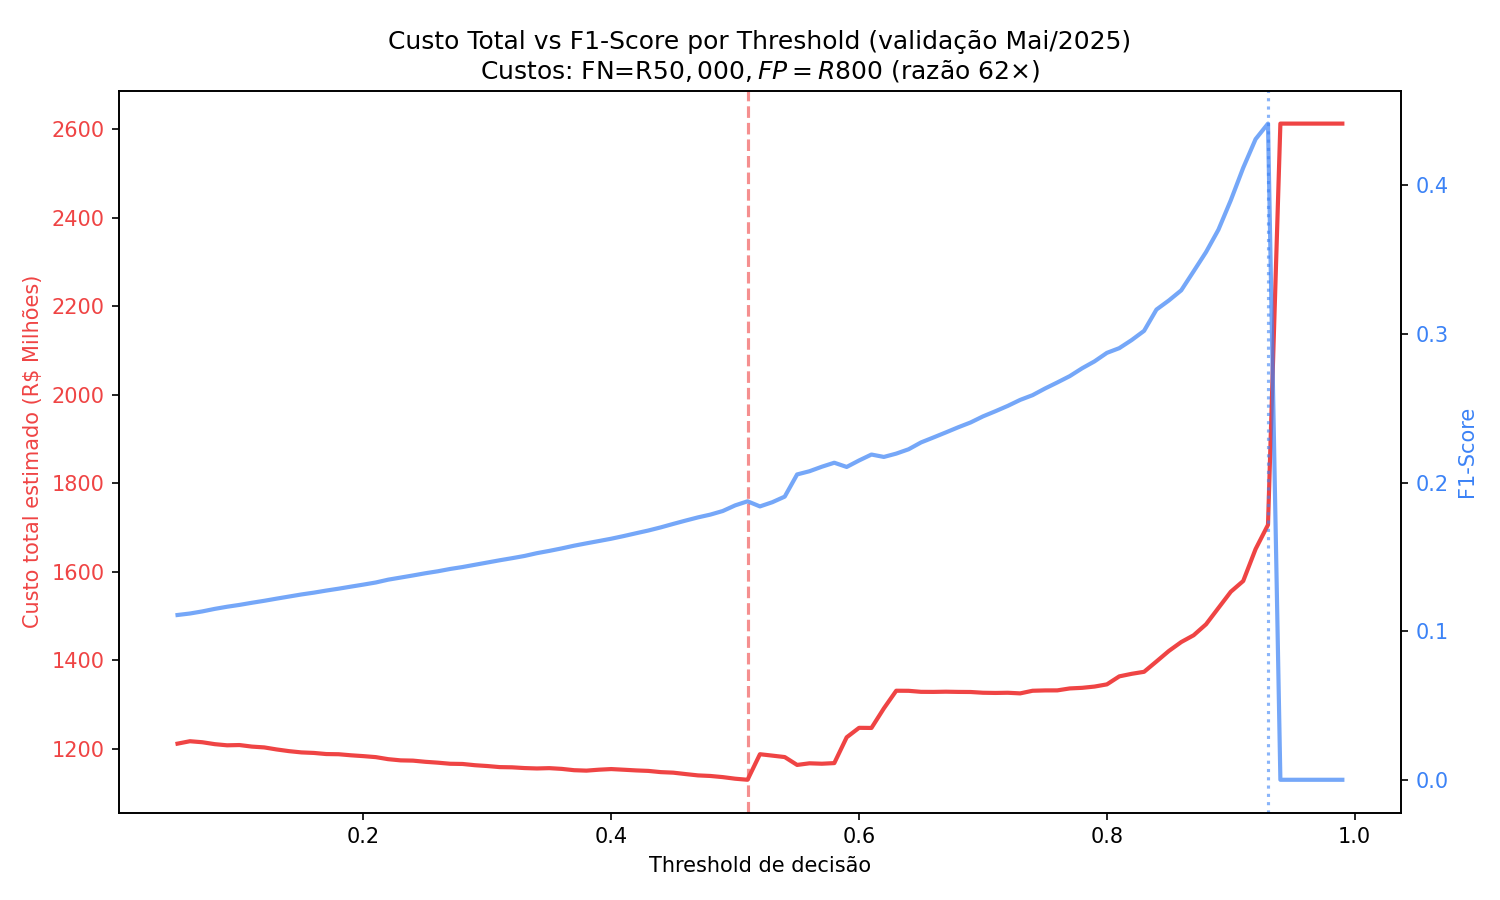

In [3]:
display(Image(filename=str(fig_dir / 'cost_vs_threshold.png')))

### Interpretação

O threshold de **F1 ótimo (~0.93)** maximiza a precisão da classificação mas, em escala operacional, deixa passar ~12.400 FNs no mês de teste — cada um representando uma parada não planejada.

O threshold **custo-ótimo (~0.51)** é mais permissivo: emite mais alertas e captura praticamente todos os DGs reais (3.287 FNs vs 12.421 — redução de ~74%). Apesar de o F1 cair (mais FPs), o custo total estimado cai em **R$ 285 milhões** no mês.

**Conclusão técnica:** em problemas de manutenção preditiva crítica, o threshold deve ser calibrado pelo custo de oportunidade real, não pelo F1 puro. O custo de um caminhão parado por horas supera dezenas de vezes o custo de uma inspeção desnecessária.

## 3. Casos representativos — Falsos Positivos

In [4]:
fp_df = pd.DataFrame(data['cases_fp'])
display(fp_df)

,Data_Evento,TAG,Tag_Frota,y_prob,n_criticos_30m,n_criticos_60m,aceleracao_criticos,minutes_to_next_dg
0,2025-06-01 23:07:47.633000,CA65935,793-D 5S,0.933847,2.0,4.0,1.454017,648.0
1,2025-06-01 23:07:52.883000,CA65935,793-D 5S,0.933847,2.0,4.0,1.454017,648.0
2,2025-06-01 23:08:35.367000,CA65935,793-D 5S,0.933847,2.0,3.0,1.090513,647.0


**Padrão observado nos FPs:** todos os 3 casos ocorrem no **CA65935 (793-D 5S)** em uma janela de ~1 minuto (01/06/2025 ~23:08). O modelo identificou aceleração de alarmes críticos e probabilidade muito alta (0.934), mas o Don't Go efetivamente não ocorreu nas próximas 60 minutos.

**Hipótese:** o operador ou a manutenção interveio antes do disparo do Don't Go, ou o limite OEM não foi atingido apesar do sinal estatístico. Esses casos não são exatamente "erros" do modelo — refletem situações de **alto risco que foram mitigadas**. Em operação real, esses alertas teriam motivado intervenção preventiva — exatamente o objetivo do sistema.

## 4. Casos representativos — Falsos Negativos

In [5]:
fn_df = pd.DataFrame(data['cases_fn'])
display(fn_df)

,Data_Evento,TAG,Tag_Frota,y_prob,n_criticos_30m,n_criticos_60m,aceleracao_criticos,minutes_to_next_dg
0,2025-06-02 11:59:20.013000,PE3797,LeTourneau L 1850,0.012440,0.0,0.0,0.0,41.0
1,2025-06-02 12:07:53.930000,PE3797,LeTourneau L 1850,0.012440,0.0,0.0,0.0,33.0
2,2025-06-02 11:41:19.427000,PE3797,LeTourneau L 1850,0.012442,0.0,0.0,0.0,59.0


**Padrão observado nos FNs:** todos os 3 casos ocorrem em **PE3797 (LeTourneau L 1850)** — escavadeira, não caminhão. A probabilidade prevista é praticamente nula (0.012), `n_criticos_30m = 0` e `aceleracao_criticos = 0`. **Não havia sinal nenhum nas features de alarme**, mas o Don't Go ocorreu em 30-60 minutos.

**Diagnóstico crítico:** escavadeiras LeTourneau apresentam **padrão de falha distinto** dos caminhões 793-D. Os alarmes que precedem Don't Go nestes equipamentos não estão capturados pelo fingerprint atual (top-30 alarmes mais frequentes — dominados por caminhões). Esta é uma **limitação documentada do modelo**.

**Recomendação para trabalhos futuros:** treinar modelo separado para escavadeiras ou enriquecer o fingerprint com alarmes específicos de LeTourneau.

## 5. Distribuição de Probabilidades por Classe

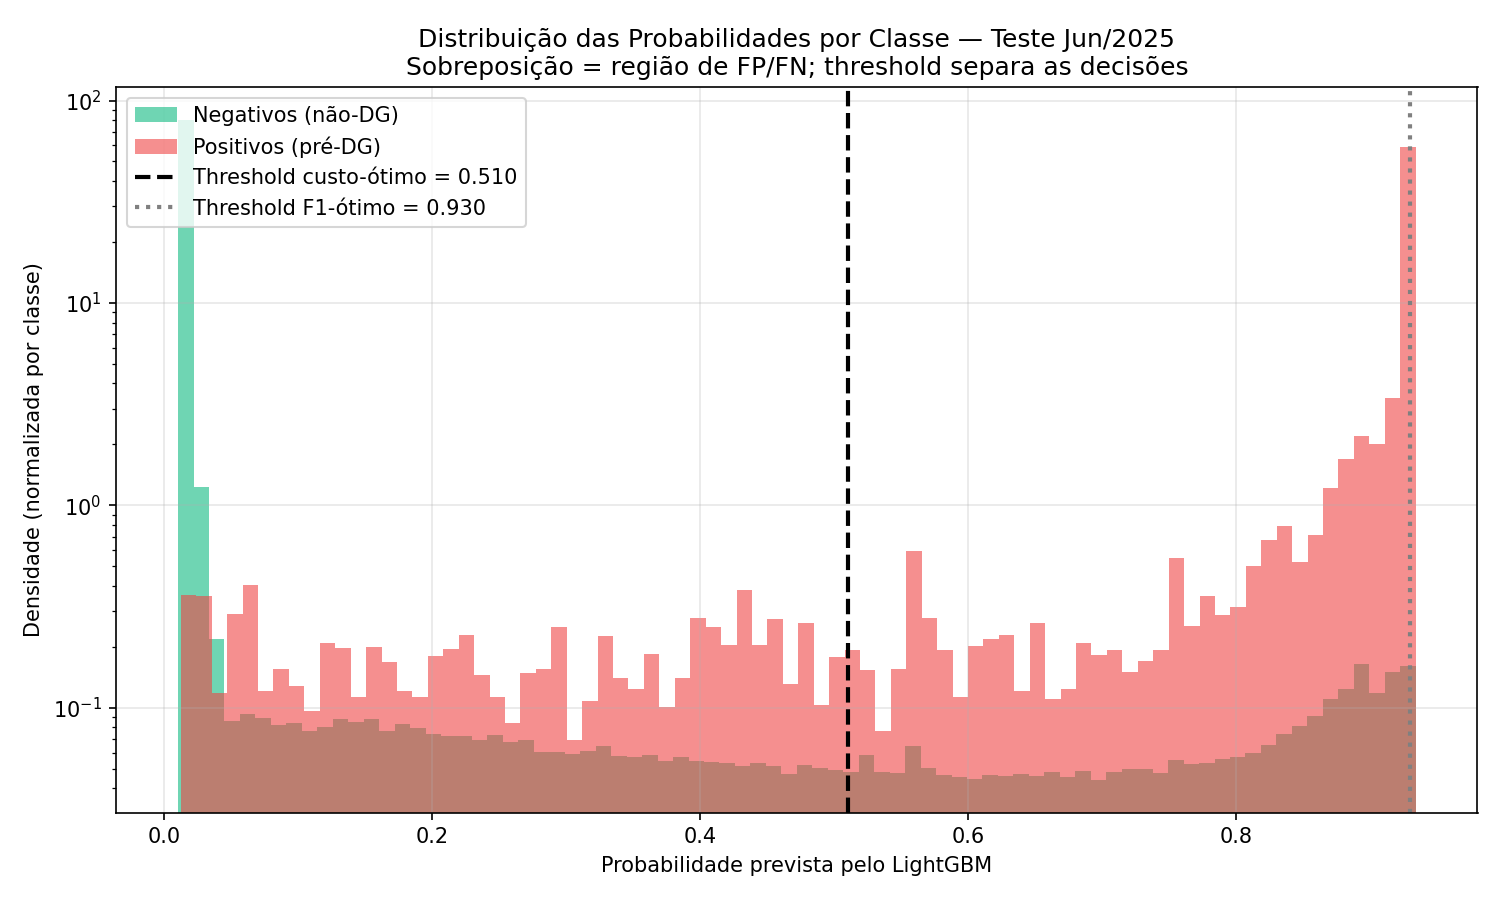

In [6]:
display(Image(filename=str(fig_dir / 'prob_distribution_by_class.png')))

A separação entre as duas distribuições é boa nos extremos, mas há sobreposição significativa na região 0.1–0.7 — onde a maioria dos FP/FN ocorre. O threshold custo-ótimo (0.51) corta essa região de incerteza priorizando capturar verdadeiros positivos.